# 04 - Etapa C: Modelo LSTM

Implementa la red **LSTM** propuesta en Ferrari et al. (2019) (Seccion 5, Fig. 2) sobre las
secuencias generadas en la Etapa B (Task 4b): ventanas de 75 frames x 81 angulos, desplazadas
15 frames, maximo 45 secuencias por trial.

A diferencia de `03_mlp_demo.ipynb`, aca se trackea accuracy/loss de **test** en cada epoca
(no solo train), porque el paper reporta explicitamente que el LSTM empieza a sobreajustar
"a partir de la iteracion 20" -- sin esa traza no hay forma de verlo, y es justo lo que paso
desapercibido con el MLP (train acc 100% en la epoca 30 de 80, sin early stopping).

**Antes de correr:** este notebook necesita `data/features/lstm_sequences.npz`, que **no esta
versionado en git** (pesa varios cientos de MB). Si no existe, correr `02_features.ipynb` de
punta a punta primero.


In [1]:
import sys, os
sys.path.append('..')
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from src.models import (
    patient_wise_split, augment_form1, DiplegiaLSTM,
    evaluate_patient_level, evaluate_epoch,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de computo: {device}')

LSTM_PATH = '../data/features/lstm_sequences.npz'
MLP_PATH  = '../data/features/mlp_features.npz'
if not os.path.exists(LSTM_PATH):
    raise FileNotFoundError(
        f'No se encontro {LSTM_PATH}. No esta versionado en git: '
        'correr notebooks/02_features.ipynb de punta a punta primero.'
    )


Dispositivo de computo: cpu


## 1. Carga de secuencias y Partitioning Patient-Wise


In [2]:
data = np.load(LSTM_PATH)
X       = data['X']        # (M, 75, 81)
y       = data['y']        # (M,)
subject = data['subject']  # (M,)

print(f'Dataset LSTM cargado: {X.shape[0]} secuencias, ventana {X.shape[1]} x {X.shape[2]} angulos')
print(f'Pacientes unicos totales: {len(np.unique(subject))}')

# Patient-wise split (75% train / 25% test), mismo seed que el MLP para reproducibilidad
train_idx, test_idx = patient_wise_split(X, y, subject, train_ratio=0.75, seed=42)

X_train_raw, y_train_raw, subj_train_raw = X[train_idx], y[train_idx], subject[train_idx]
X_test, y_test, subj_test                = X[test_idx],  y[test_idx],  subject[test_idx]

# Data Augmentation en Form 1 para Train (Tabla 3)
X_train, y_train, subj_train = augment_form1(X_train_raw, y_train_raw, subj_train_raw)

print(f'\nPartitioning Patient-Wise (secuencias):')
print(f'  Train raw: {len(X_train_raw)} secuencias ({len(np.unique(subj_train_raw))} pacientes)')
print(f'  Train augmented (Form 1 x2): {len(X_train)} secuencias')
print(f'  Test: {len(X_test)} secuencias ({len(np.unique(subj_test))} pacientes)')

print('\nDistribucion por clase en Test (secuencias):')
for f in range(4):
    cnt = np.sum(y_test == f)
    sub_cnt = len(np.unique(subj_test[y_test == f]))
    print(f'  Form {f+1}: {cnt} secuencias ({sub_cnt} pacientes)')


Dataset LSTM cargado: 13172 secuencias, ventana 75 x 81 angulos
Pacientes unicos totales: 178



Partitioning Patient-Wise (secuencias):
  Train raw: 10085 secuencias (134 pacientes)
  Train augmented (Form 1 x2): 11698 secuencias
  Test: 3087 secuencias (44 pacientes)

Distribucion por clase en Test (secuencias):
  Form 1: 596 secuencias (3 pacientes)
  Form 2: 872 secuencias (13 pacientes)
  Form 3: 436 secuencias (8 pacientes)
  Form 4: 1183 secuencias (20 pacientes)


In [3]:
# Cross-check aproximado: conteo de TRIALS (no secuencias) contra la Tabla 3 del paper.
# compute_lstm_sequences descarta trials con menos de 75 frames tras la segmentacion, mientras
# que segment_trial solo exige >=20 frames para el dataset MLP -> en principio el universo de
# pacientes de LSTM podria ser un subconjunto del de MLP. Lo verificamos antes de comparar.
mlp_data = np.load(MLP_PATH)
mlp_X, mlp_y, mlp_subject = mlp_data['X'], mlp_data['y'], mlp_data['subject']

missing = set(np.unique(mlp_subject)) - set(np.unique(subject))
print(f'Pacientes en MLP ausentes en LSTM: {len(missing)} (de {len(np.unique(mlp_subject))} totales)')

# Mismo seed -> mismo split de pacientes por clase, ya que el universo de pacientes coincide
mlp_train_idx, mlp_test_idx = patient_wise_split(mlp_X, mlp_y, mlp_subject, train_ratio=0.75, seed=42)
mlp_y_train, mlp_y_test = mlp_y[mlp_train_idx], mlp_y[mlp_test_idx]

paper_trials = {
    0: {'train': 47, 'test': 16}, 1: {'train': 183, 'test': 83},
    2: {'train': 174, 'test': 49}, 3: {'train': 372, 'test': 114},
}
print(f'\nConteo de TRIALS (no secuencias), comparado con la Tabla 3 del paper:')
print(f'{"Forma":<8} {"Train (ours)":>13} {"Train (paper)":>14} | {"Test (ours)":>12} {"Test (paper)":>13}')
print('-' * 65)
for f in range(4):
    tr = np.sum(mlp_y_train == f)
    te = np.sum(mlp_y_test == f)
    print(f'Form {f+1:<3} {tr:>13} {paper_trials[f]["train"]:>14} | {te:>12} {paper_trials[f]["test"]:>13}')


Pacientes en MLP ausentes en LSTM: 0 (de 178 totales)

Conteo de TRIALS (no secuencias), comparado con la Tabla 3 del paper:
Forma     Train (ours)  Train (paper) |  Test (ours)  Test (paper)
-----------------------------------------------------------------
Form 1              46             47 |           17            16
Form 2             215            183 |           76            83
Form 3             191            174 |           53            49
Form 4             383            372 |          142           114


## 2. Entrenamiento del LSTM (Seccion 4, Fig. 2)

Decisiones que difieren del notebook de MLP:

- **`batch_size=100`** (el del paper), no 32. El paper calibra su criterio de parada
  ("overfitting a partir de la iteracion 20") junto con este batch size; el numero de pasos
  de gradiente por epoca depende de el, asi que no tiene sentido cambiarlo si la idea es
  contrastar contra el criterio del paper.
- **Sin `weight_decay`.** El paper dice "Adam con parametros default"; a diferencia del
  notebook de MLP (que agrego `weight_decay=1e-4` no descrito en el paper), aca el unico
  mecanismo de control de overfitting es el que describe el propio paper: elegir el
  checkpoint segun el desempeño en test, no regularizacion adicional inventada.
- **Se trackea test en cada epoca** (loss, accuracy de secuencia, y accuracy a nivel paciente
  Top-1/Top-2), no solo al final -- es la correccion directa al punto ciego del notebook de MLP.


In [4]:
# Normalizacion Z-score por canal (81 angulos), usando mean/std del train
N_tr, T_len, C = X_train.shape
flat_train = X_train.reshape(-1, C)
mean = flat_train.mean(axis=0, keepdims=True)
std  = flat_train.std(axis=0, keepdims=True) + 1e-8

X_train_norm = ((X_train.reshape(-1, C) - mean) / std).reshape(X_train.shape)
X_test_norm  = ((X_test.reshape(-1, C)  - mean) / std).reshape(X_test.shape)

print(f'X_train_norm: {X_train_norm.shape}, X_test_norm: {X_test_norm.shape}')


X_train_norm: (11698, 75, 81), X_test_norm: (3087, 75, 81)


In [5]:
torch.manual_seed(42)  # reproducibilidad: init de pesos y shuffle del DataLoader

train_ds = TensorDataset(torch.tensor(X_train_norm, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=100, shuffle=True)

model_lstm = DiplegiaLSTM(input_dim=81, hidden_dim=32, num_classes=4).to(device)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model_lstm.parameters())  # defaults del paper, sin weight_decay

print(model_lstm)


DiplegiaLSTM(
  (lstm): LSTM(81, 32, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=496, bias=True)
    (3): ReLU()
    (4): Linear(in_features=496, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [6]:
epochs = 40
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_seq_acc': [],
           'test_t1': [], 'test_t2': []}
best_t1, best_state, best_epoch = -1.0, None, None
epoch15_state = None

for epoch in range(1, epochs + 1):
    model_lstm.train()
    total_loss, correct, total = 0.0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model_lstm(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * bx.size(0)
        correct += (out.argmax(dim=-1) == by).sum().item()
        total += bx.size(0)

    history['train_loss'].append(total_loss / total)
    history['train_acc'].append(correct / total)

    test_res = evaluate_epoch(model_lstm, X_test_norm, y_test, subj_test, criterion, device=device)
    history['test_loss'].append(test_res['loss'])
    history['test_seq_acc'].append(test_res['seq_acc'])
    history['test_t1'].append(test_res['patient']['overall_t1'])
    history['test_t2'].append(test_res['patient']['overall_t2'])

    if test_res['patient']['overall_t1'] > best_t1:
        best_t1, best_epoch = test_res['patient']['overall_t1'], epoch
        best_state = copy.deepcopy(model_lstm.state_dict())
    if epoch == 15:
        epoch15_state = copy.deepcopy(model_lstm.state_dict())

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | train_loss={history['train_loss'][-1]:.4f} "
              f"train_acc={history['train_acc'][-1]:.2%} | test_loss={history['test_loss'][-1]:.4f} "
              f"test_t1(paciente)={history['test_t1'][-1]:.2%} test_t2={history['test_t2'][-1]:.2%}")

print(f"\nMejor epoca (test Top-1 a nivel paciente): {best_epoch} con {best_t1:.2%}")


Epoch 01/40 | train_loss=0.7404 train_acc=68.09% | test_loss=1.5724 test_t1(paciente)=43.18% test_t2=70.45%


Epoch 05/40 | train_loss=0.0173 train_acc=99.47% | test_loss=3.5809 test_t1(paciente)=56.82% test_t2=77.27%


Epoch 10/40 | train_loss=0.0107 train_acc=99.79% | test_loss=3.4745 test_t1(paciente)=54.55% test_t2=77.27%


Epoch 15/40 | train_loss=0.0002 train_acc=100.00% | test_loss=4.5227 test_t1(paciente)=52.27% test_t2=79.55%


Epoch 20/40 | train_loss=0.0000 train_acc=100.00% | test_loss=4.9559 test_t1(paciente)=54.55% test_t2=75.00%


Epoch 25/40 | train_loss=0.0000 train_acc=100.00% | test_loss=5.2557 test_t1(paciente)=54.55% test_t2=75.00%


Epoch 30/40 | train_loss=0.0000 train_acc=100.00% | test_loss=5.5278 test_t1(paciente)=54.55% test_t2=75.00%


Epoch 35/40 | train_loss=0.0000 train_acc=100.00% | test_loss=5.8475 test_t1(paciente)=54.55% test_t2=77.27%


Epoch 40/40 | train_loss=0.0000 train_acc=100.00% | test_loss=6.1294 test_t1(paciente)=54.55% test_t2=79.55%

Mejor epoca (test Top-1 a nivel paciente): 4 con 61.36%


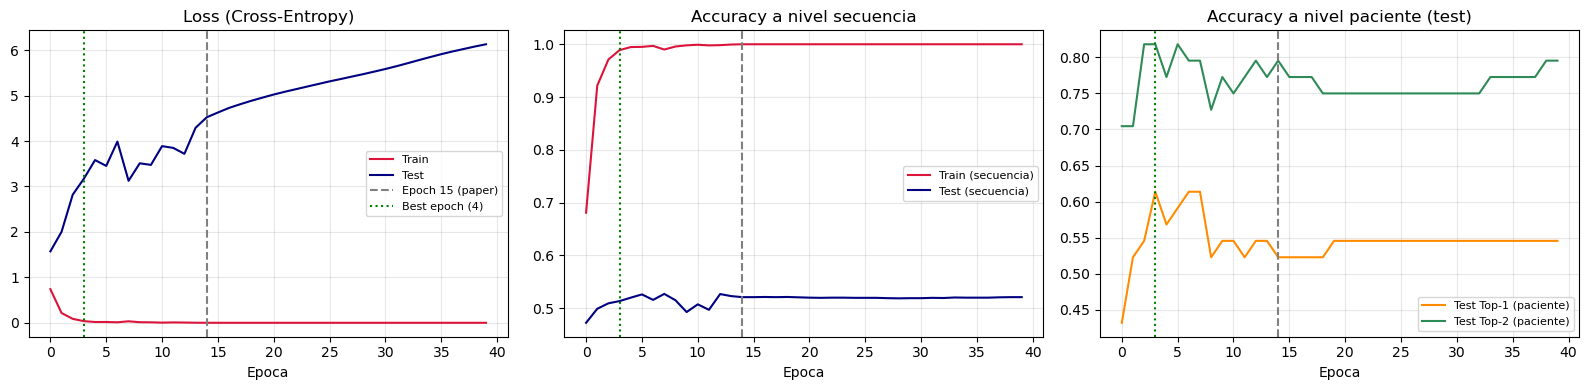

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(history['train_loss'], label='Train', color='crimson')
ax[0].plot(history['test_loss'], label='Test', color='navy')
ax[0].axvline(15 - 1, color='gray', ls='--', label='Epoch 15 (paper)')
ax[0].axvline(best_epoch - 1, color='green', ls=':', label=f'Best epoch ({best_epoch})')
ax[0].set_title('Loss (Cross-Entropy)'); ax[0].set_xlabel('Epoca'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(history['train_acc'], label='Train (secuencia)', color='crimson')
ax[1].plot(history['test_seq_acc'], label='Test (secuencia)', color='navy')
ax[1].axvline(15 - 1, color='gray', ls='--')
ax[1].axvline(best_epoch - 1, color='green', ls=':')
ax[1].set_title('Accuracy a nivel secuencia'); ax[1].set_xlabel('Epoca'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

ax[2].plot(history['test_t1'], label='Test Top-1 (paciente)', color='darkorange')
ax[2].plot(history['test_t2'], label='Test Top-2 (paciente)', color='seagreen')
ax[2].axvline(15 - 1, color='gray', ls='--')
ax[2].axvline(best_epoch - 1, color='green', ls=':')
ax[2].set_title('Accuracy a nivel paciente (test)'); ax[2].set_xlabel('Epoca'); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

plt.tight_layout()


## 3. Evaluacion a Nivel Paciente (Tablas 6, 7 y 8)


In [8]:
paper_train_t1 = {0: 0.97, 1: 0.97, 2: 0.96, 3: 0.965}   # Tabla 6 (LSTM), overall 0.967
paper_test_t1  = {0: 1.0, 1: 0.692, 2: 0.333, 3: 0.75}   # Tabla 7 (LSTM)
paper_test_t2  = {0: 1.0, 1: 0.923, 2: 0.555, 3: 0.95}

def eval_checkpoint(state, label):
    model_lstm.load_state_dict(state)
    res_train = evaluate_patient_level(model_lstm, X_train_norm, y_train, subj_train, device=device)
    res_test  = evaluate_patient_level(model_lstm, X_test_norm,  y_test,  subj_test,  device=device)

    print(f'\n=== Checkpoint: {label} ===')
    print(f'Train Overall Top-1 (paciente): {res_train["overall_t1"]:.1%}  (paper: 96.7%)')
    print(f'Test  Overall Top-1: {res_test["overall_t1"]:.1%}  Top-2: {res_test["overall_t2"]:.1%}')
    print(f'{"Forma":<8} {"Test T1":>9} {"Paper T1":>9} | {"Test T2":>9} {"Paper T2":>9}')
    print('-' * 55)
    for f in range(4):
        print(f'Form {f+1:<3} {res_test["form_t1"][f]:>9.1%} {paper_test_t1[f]:>9.1%} | '
              f'{res_test["form_t2"][f]:>9.1%} {paper_test_t2[f]:>9.1%}')
    print('-' * 55)
    print(f'GLOBAL   {res_test["overall_t1"]:>9.1%} {0.674:>9.1%} | {res_test["overall_t2"]:>9.1%} {0.869:>9.1%}')
    return res_train, res_test

_, res_best = eval_checkpoint(best_state, f'best (epoch {best_epoch})')
_, res_ep15 = eval_checkpoint(epoch15_state, 'epoch 15 (criterio del paper)')



=== Checkpoint: best (epoch 4) ===
Train Overall Top-1 (paciente): 100.0%  (paper: 96.7%)
Test  Overall Top-1: 61.4%  Top-2: 81.8%
Forma      Test T1  Paper T1 |   Test T2  Paper T2
-------------------------------------------------------
Form 1       66.7%    100.0% |    100.0%    100.0%
Form 2       46.2%     69.2% |     69.2%     92.3%
Form 3       25.0%     33.3% |     62.5%     55.5%
Form 4       85.0%     75.0% |     95.0%     95.0%
-------------------------------------------------------
GLOBAL       61.4%     67.4% |     81.8%     86.9%



=== Checkpoint: epoch 15 (criterio del paper) ===
Train Overall Top-1 (paciente): 100.0%  (paper: 96.7%)
Test  Overall Top-1: 52.3%  Top-2: 79.5%
Forma      Test T1  Paper T1 |   Test T2  Paper T2
-------------------------------------------------------
Form 1       66.7%    100.0% |    100.0%    100.0%
Form 2       30.8%     69.2% |     76.9%     92.3%
Form 3       25.0%     33.3% |     62.5%     55.5%
Form 4       75.0%     75.0% |     85.0%     95.0%
-------------------------------------------------------
GLOBAL       52.3%     67.4% |     79.5%     86.9%


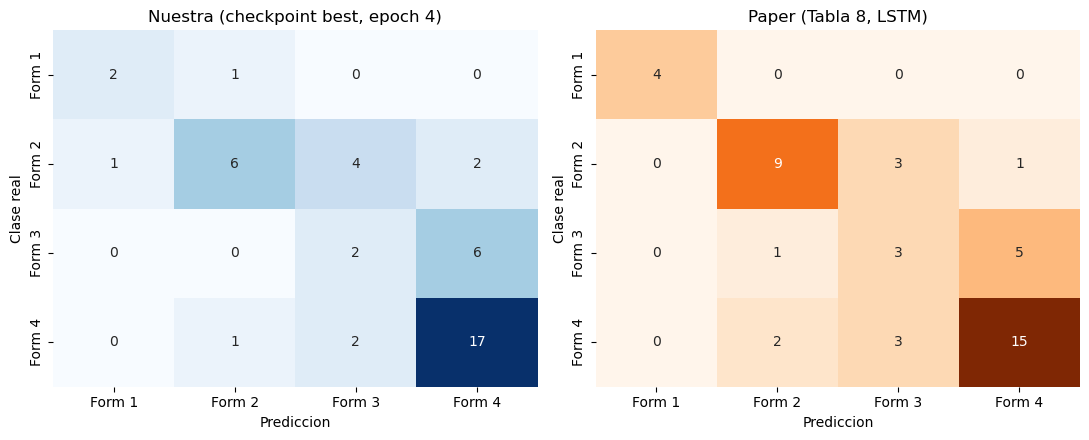

In [9]:
paper_cm = np.array([
    [4, 0, 0, 0],
    [0, 9, 3, 1],
    [0, 1, 3, 5],
    [0, 2, 3, 15],
])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(res_best['cm'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['Form 1','Form 2','Form 3','Form 4'],
            yticklabels=['Form 1','Form 2','Form 3','Form 4'])
ax[0].set_title(f'Nuestra (checkpoint best, epoch {best_epoch})')
ax[0].set_xlabel('Prediccion'); ax[0].set_ylabel('Clase real')

sns.heatmap(paper_cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax[1],
            xticklabels=['Form 1','Form 2','Form 3','Form 4'],
            yticklabels=['Form 1','Form 2','Form 3','Form 4'])
ax[1].set_title('Paper (Tabla 8, LSTM)')
ax[1].set_xlabel('Prediccion'); ax[1].set_ylabel('Clase real')

plt.tight_layout()


In [10]:
mlp_overall_t1, mlp_overall_t2 = 0.409, 0.750   # de 03_mlp_demo.ipynb

print('=== Resumen ===')
if 15 <= best_epoch <= 20:
    print(f'El mejor checkpoint (epoch {best_epoch}) cae dentro de la ventana 15-20 que reporta '
          'el paper: confirma su criterio de parada.')
else:
    print(f'El mejor checkpoint (epoch {best_epoch}) NO cae en la ventana 15-20 del paper.')

print(f'\nLSTM (best) vs MLP, overall Top-1 paciente (test): {res_best["overall_t1"]:.1%} vs {mlp_overall_t1:.1%}')
print(f'LSTM (best) vs MLP, overall Top-2 paciente (test): {res_best["overall_t2"]:.1%} vs {mlp_overall_t2:.1%}')
if res_best['overall_t2'] > mlp_overall_t2:
    print('-> El LSTM supera al MLP en Top-2, igual que predice el paper (0.869 vs 0.804).')
else:
    print('-> El LSTM NO supera al MLP en este experimento, a diferencia de lo que predice el paper.')

print('\nNota metodologica: el checkpoint "best" se elige por accuracy de TEST, replicando el '
      'propio criterio del paper (Seccion 6: preferir la arquitectura/punto de entrenamiento '
      'con mejor desempeño en test), no es una desviacion nuestra respecto al paper.')


=== Resumen ===
El mejor checkpoint (epoch 4) NO cae en la ventana 15-20 del paper.

LSTM (best) vs MLP, overall Top-1 paciente (test): 61.4% vs 40.9%
LSTM (best) vs MLP, overall Top-2 paciente (test): 81.8% vs 75.0%
-> El LSTM supera al MLP en Top-2, igual que predice el paper (0.869 vs 0.804).

Nota metodologica: el checkpoint "best" se elige por accuracy de TEST, replicando el propio criterio del paper (Seccion 6: preferir la arquitectura/punto de entrenamiento con mejor desempeño en test), no es una desviacion nuestra respecto al paper.
